In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-08 10:27:21.481560


# Create AnnData from Xenium output folders

**Pinned Environment:** [`envs/sc-spatial.yaml`](../.../envs/sc-spatial.yaml)

In [2]:
import sys
from pathlib import Path
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import math
import session_info

In [3]:
plt.rcParams['figure.dpi'] = 150

## Set paths

In [4]:
base_dir = Path('/home/workspace/projects/drg')

data_input_folder = base_dir / 'download/isolon'
fig_dir = base_dir / 'figures/qc'
h5ad_dir = base_dir / 'data/h5ad/export_01/01a_raw/output_folder'
metadata_dir = base_dir / 'metadata'

# Create directories
base_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
h5ad_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)

In [5]:
sample_id_mapping = {
    "output-XETG00123__0052281__TMA00303__20251108__004334": {"region": "TMA00303", "slide": "0052281"},
    "output-XETG00123__0052334__TMA00304__20251108__004334": {"region": "TMA00304", "slide": "0052334"},
    "output-XETG00123__0052281__TMA00305__20251108__004334": {"region": "TMA00305", "slide": "0052281"},
    "output-XETG00123__0052334__TMA00306__20251108__004334": {"region": "TMA00306", "slide": "0052334"},
    "output-XETG00123__0052046__TMA00307__20251119__221941": {"region": "TMA00307", "slide": "0052046"},
    "output-XETG00123__0052399__TMA00308__20251119__221941": {"region": "TMA00308", "slide": "0052399"},
    "output-XETG00123__0052046__TMA00311__20251119__221941": {"region": "TMA00311", "slide": "0052046"},
    "output-XETG00123__0052399__TMA00312__20251119__221941": {"region": "TMA00312", "slide": "0052399"},
    "output-XETG00123__0051689__TMA00309__20251203__231448": {"region": "TMA00309", "slide": "0051689"},
    "output-XETG00123__0051805__TMA00310__20251203__231448": {"region": "TMA00310", "slide": "0051805"},
    "output-XETG00123__0051689__TMA00313__20251203__231448": {"region": "TMA00313", "slide": "0051689"},
    "output-XETG00123__0051805__TMA00314__20251203__231448": {"region": "TMA00314", "slide": "0051805"},
}

## Functions

In [6]:
def h5_to_adata(directory, sample_id):
    # File names    
    h5_file = os.path.join(directory, 'cell_feature_matrix.h5')
    cells_file = os.path.join(directory, 'cells.csv.gz')

    # h5 to adata
    adata = sc.read_10x_h5(
        filename=h5_file
    )

    # cells file
    df = pd.read_csv(
        cells_file, 
        compression='gzip'
    )

    # Set index
    df.set_index(adata.obs_names, inplace=True)
    adata.obs = df.copy()

    # x, y coordinates
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

    # Add sample metadata
    adata.obs['sample_id'] = sample_id

    return adata

## Create sample dictionary

In [7]:
directory_to_sample = {
    os.path.join(data_input_folder, subdir): f"{subdir}"
    for subdir in os.listdir(data_input_folder) if os.path.isdir(os.path.join(data_input_folder, subdir))
    if os.path.isdir(os.path.join(data_input_folder, subdir)) and not subdir.startswith(".")  # Excludes hidden folders like .ipynb_checkpoints
}

print(directory_to_sample)

{'/home/workspace/projects/drg/download/isolon/output-XETG00123__0052399__TMA00312__20251119__221941': 'output-XETG00123__0052399__TMA00312__20251119__221941', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0051689__TMA00313__20251203__231448': 'output-XETG00123__0051689__TMA00313__20251203__231448', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0051689__TMA00309__20251203__231448': 'output-XETG00123__0051689__TMA00309__20251203__231448', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00305__20251108__004334': 'output-XETG00123__0052281__TMA00305__20251108__004334', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0051805__TMA00310__20251203__231448': 'output-XETG00123__0051805__TMA00310__20251203__231448', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0051805__TMA00314__20251203__231448': 'output-XETG00123__0051805__TMA00314__20251203__231448', '/home/workspace/projects/drg/download/isolon

## Create anndata

In [8]:
# Loop through each key-value pair in the dictionary
adata_list = []
for directory, output_id in directory_to_sample.items():
    print(f"Processing: {directory} -> Run ID: {output_id}")
    adata = h5_to_adata(directory, output_id)
    adata.obs["output_id"] = output_id  
    adata_list.append(adata)

Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052399__TMA00312__20251119__221941 -> Run ID: output-XETG00123__0052399__TMA00312__20251119__221941
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0051689__TMA00313__20251203__231448 -> Run ID: output-XETG00123__0051689__TMA00313__20251203__231448
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0051689__TMA00309__20251203__231448 -> Run ID: output-XETG00123__0051689__TMA00309__20251203__231448
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00305__20251108__004334 -> Run ID: output-XETG00123__0052281__TMA00305__20251108__004334
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0051805__TMA00310__20251203__231448 -> Run ID: output-XETG00123__0051805__TMA00310__20251203__231448
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0051805__TMA00314__20251203__231448 -> Run ID

In [9]:
for adata in adata_list:
    adata.obs["sample_id"] = adata.obs["output_id"].map(lambda x: sample_id_mapping[x]["region"])
    adata.obs["region_id"] = adata.obs["sample_id"]
    adata.obs["slide_id"]  = adata.obs["output_id"].map(lambda x: sample_id_mapping[x]["slide"])

    print(adata.obs[["output_id", "sample_id", "region_id", "slide_id"]].head(1))

                                                    output_id sample_id  \
aaaijnlc-1  output-XETG00123__0052399__TMA00312__20251119_...  TMA00312   

           region_id slide_id  
aaaijnlc-1  TMA00312  0052399  
                                                    output_id sample_id  \
aaaaikjo-1  output-XETG00123__0051689__TMA00313__20251203_...  TMA00313   

           region_id slide_id  
aaaaikjo-1  TMA00313  0051689  
                                                    output_id sample_id  \
aaccbfgk-1  output-XETG00123__0051689__TMA00309__20251203_...  TMA00309   

           region_id slide_id  
aaccbfgk-1  TMA00309  0051689  
                                                    output_id sample_id  \
aaaaicce-1  output-XETG00123__0052281__TMA00305__20251108_...  TMA00305   

           region_id slide_id  
aaaaicce-1  TMA00305  0052281  
                                                    output_id sample_id  \
aafjlmef-1  output-XETG00123__0051805__TMA00310__20251203_...  TM

## QC

In [10]:
adata_list

[AnnData object with n_obs × n_vars = 21826 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 20275 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 4012 × 480
     obs: 'cell_id', 'x_cen

#### Fix order

In [11]:
adata_list = sorted(adata_list, key=lambda ad: ad.obs["sample_id"].iloc[0])

#### Visualize

TMA00303
12755 cells
TMA00304
24375 cells
TMA00305
38753 cells
TMA00306
37315 cells
TMA00307
9238 cells
TMA00308
9759 cells
TMA00309
4012 cells
TMA00310
1931 cells
TMA00311
24803 cells
TMA00312
21826 cells
TMA00313
20275 cells
TMA00314
17792 cells


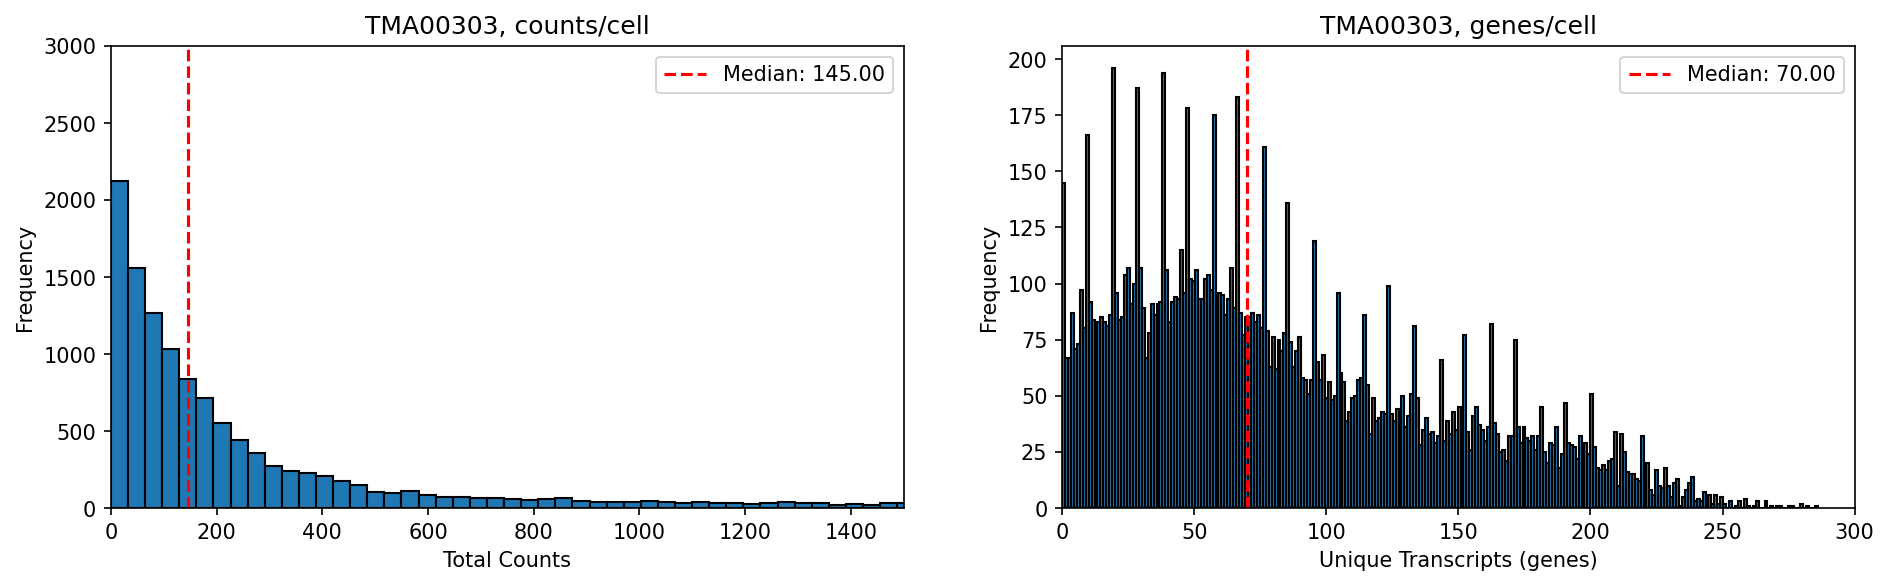

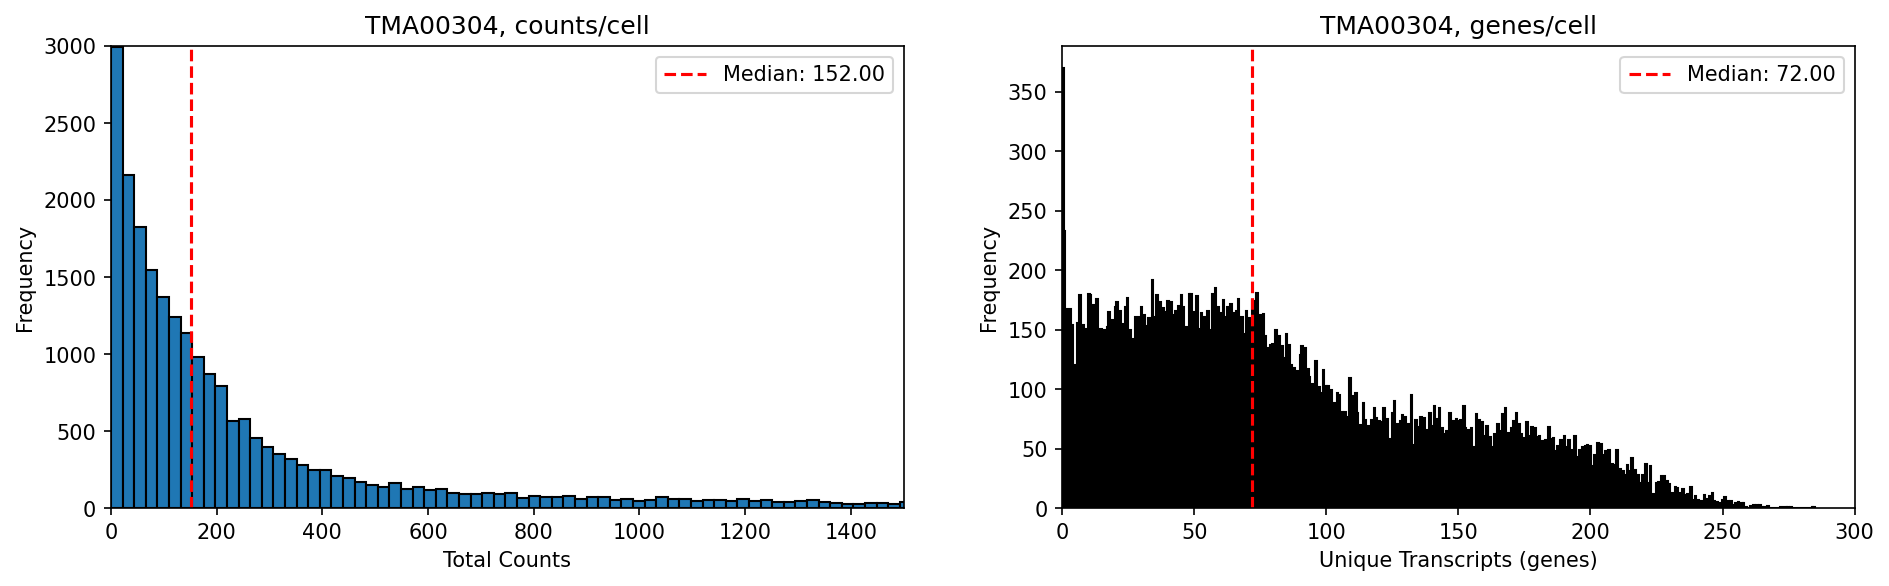

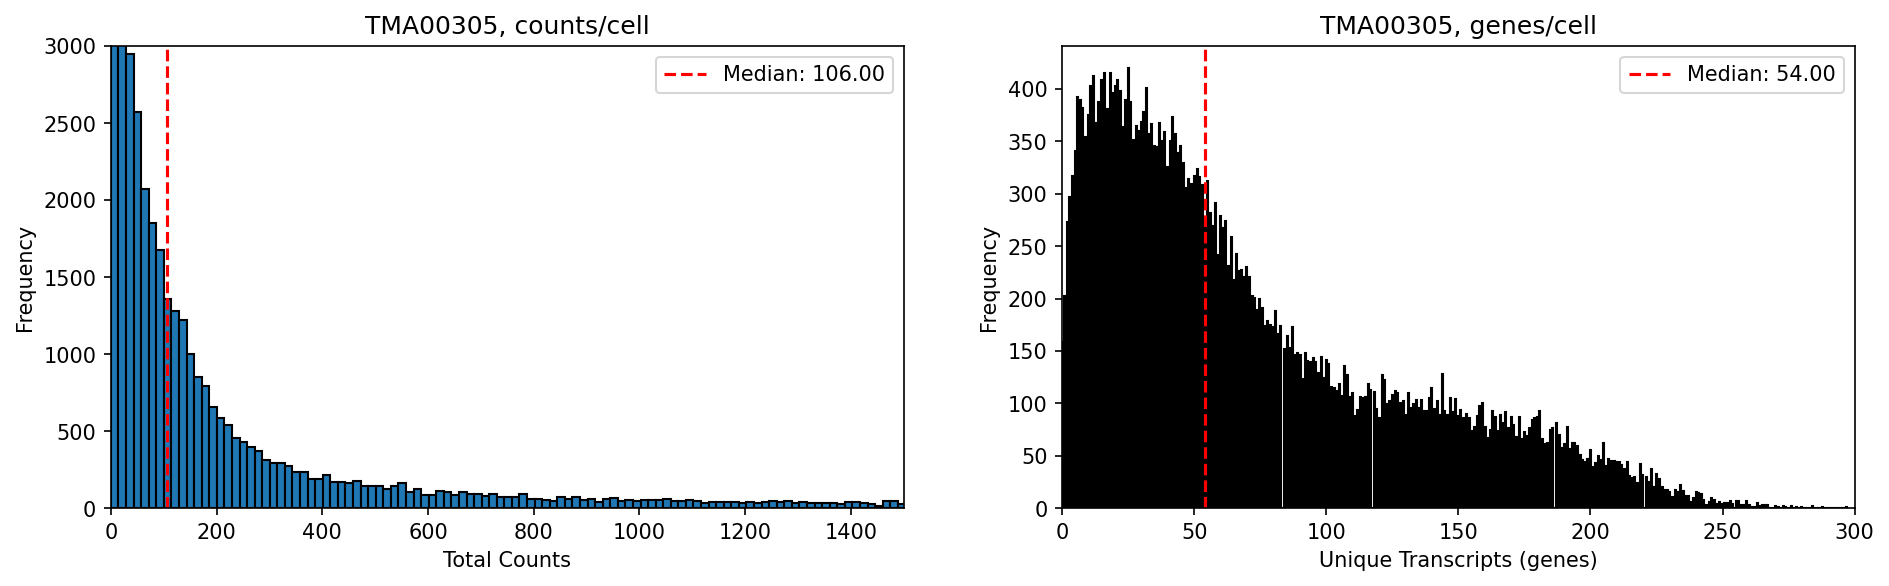

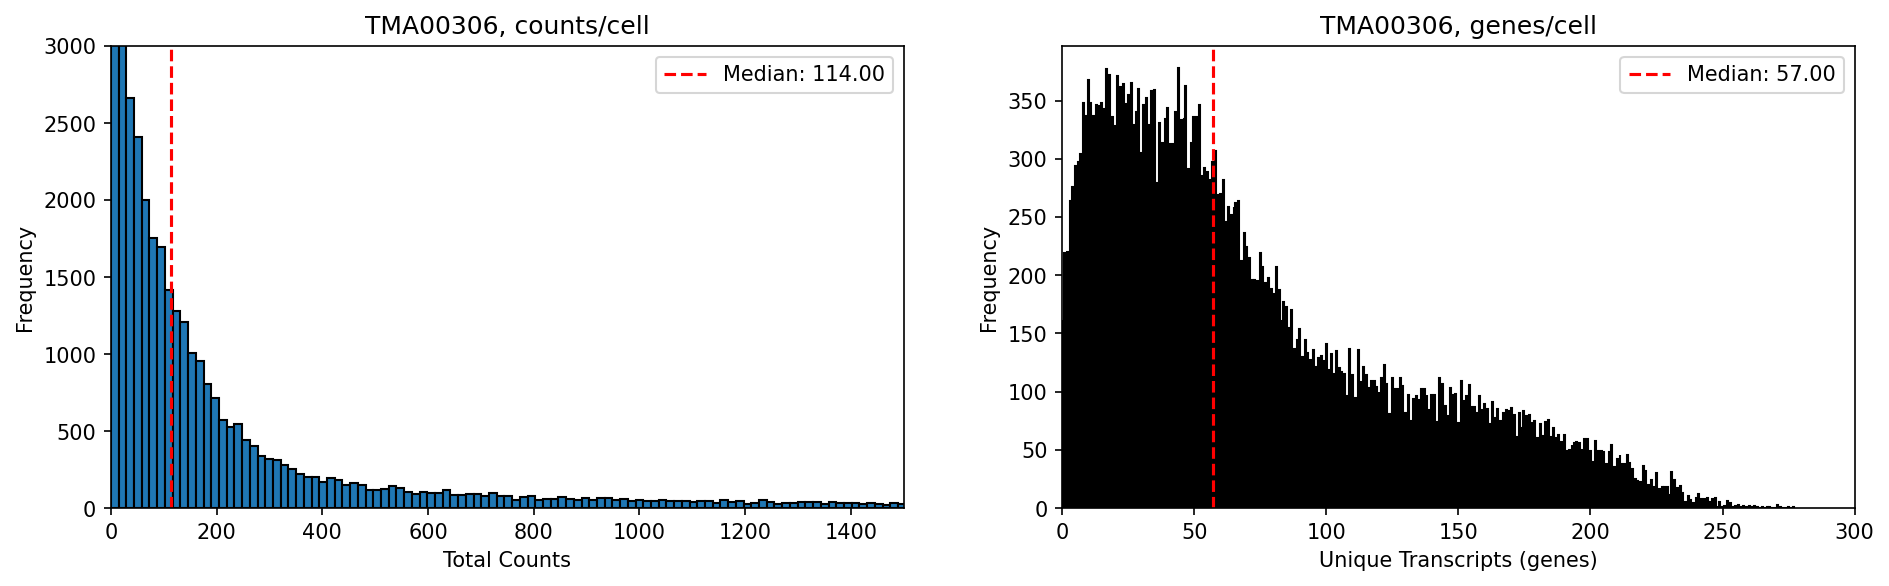

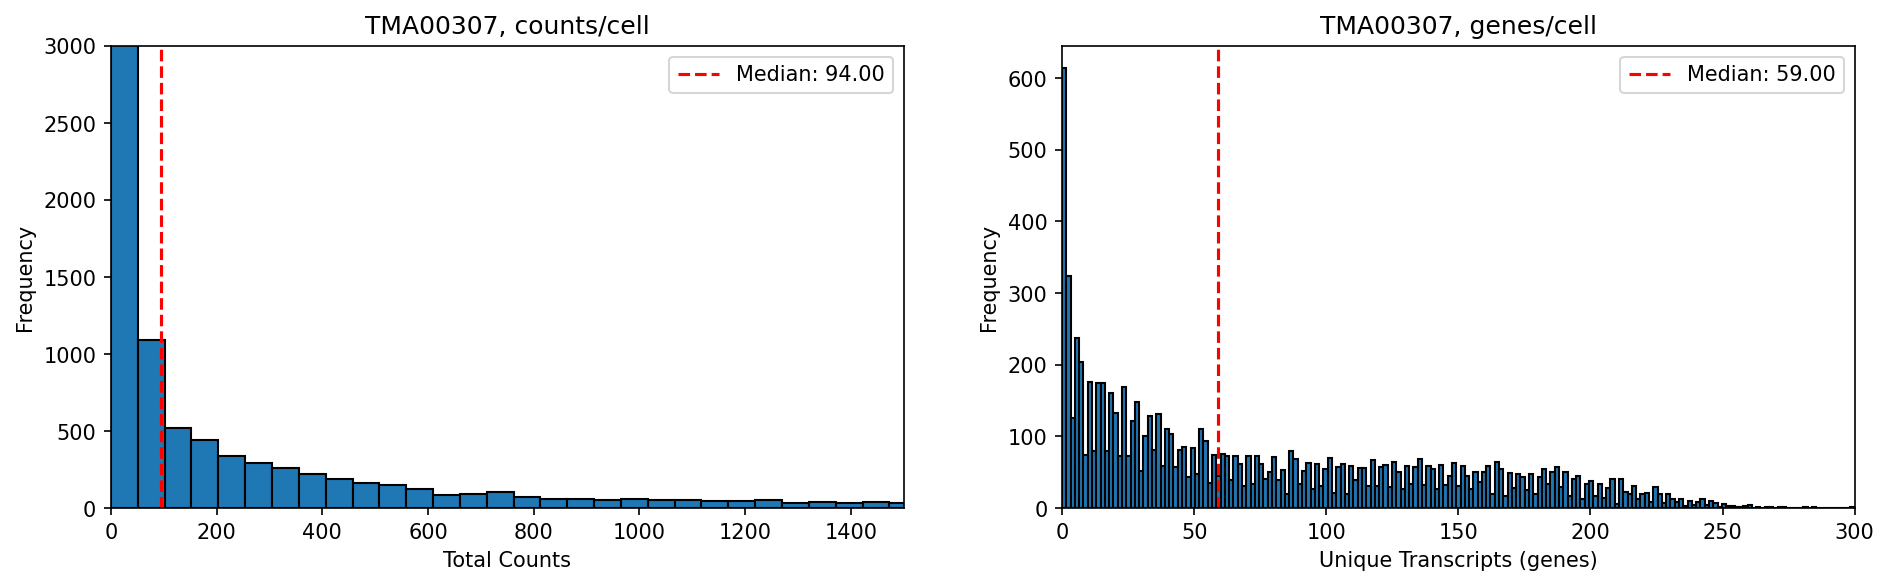

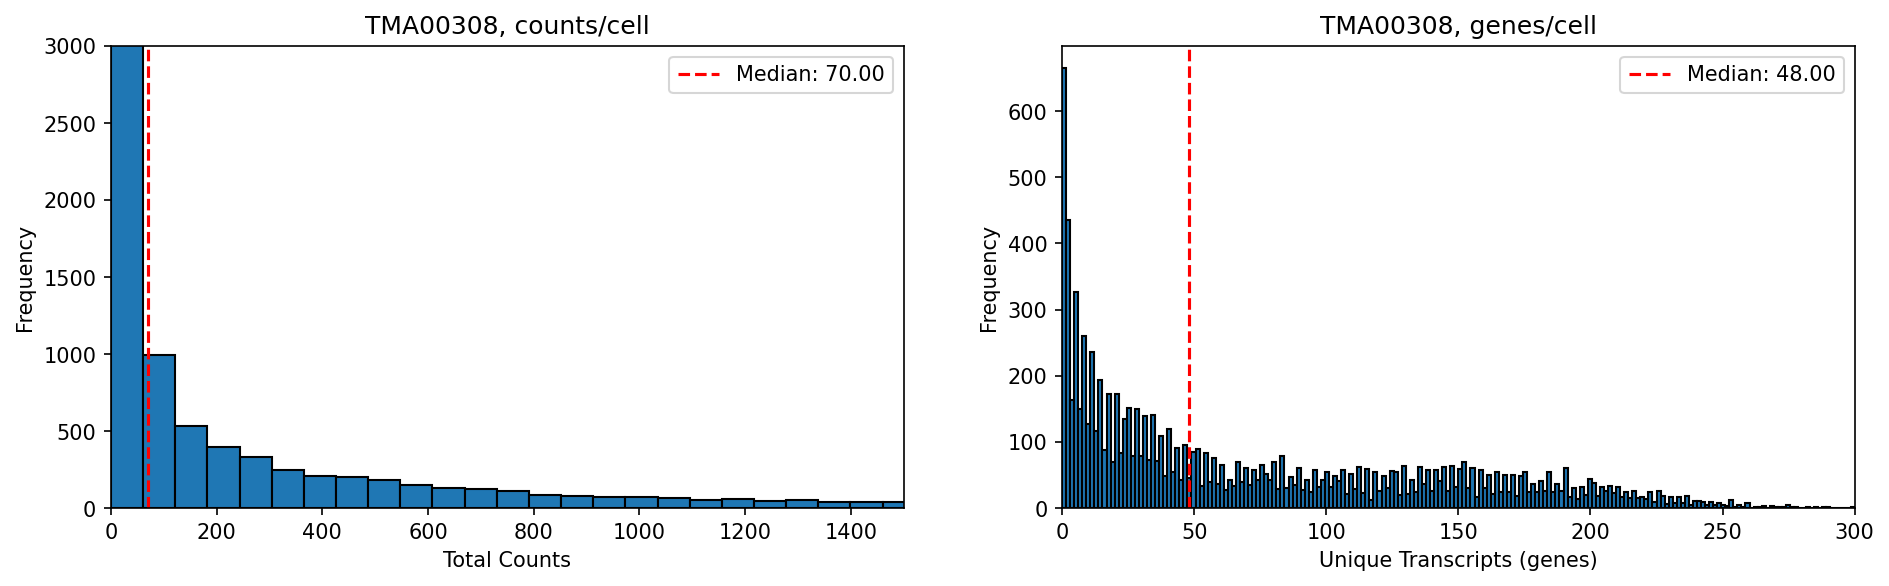

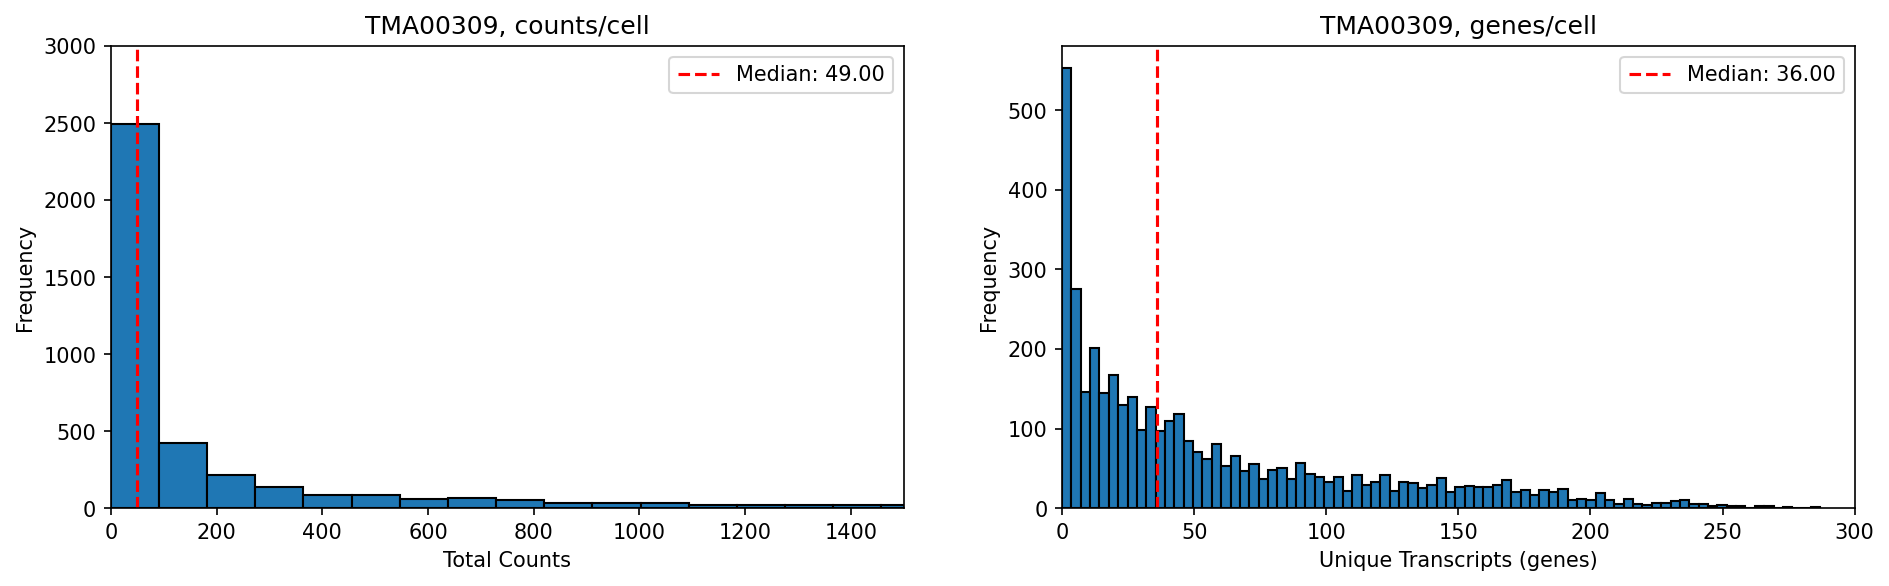

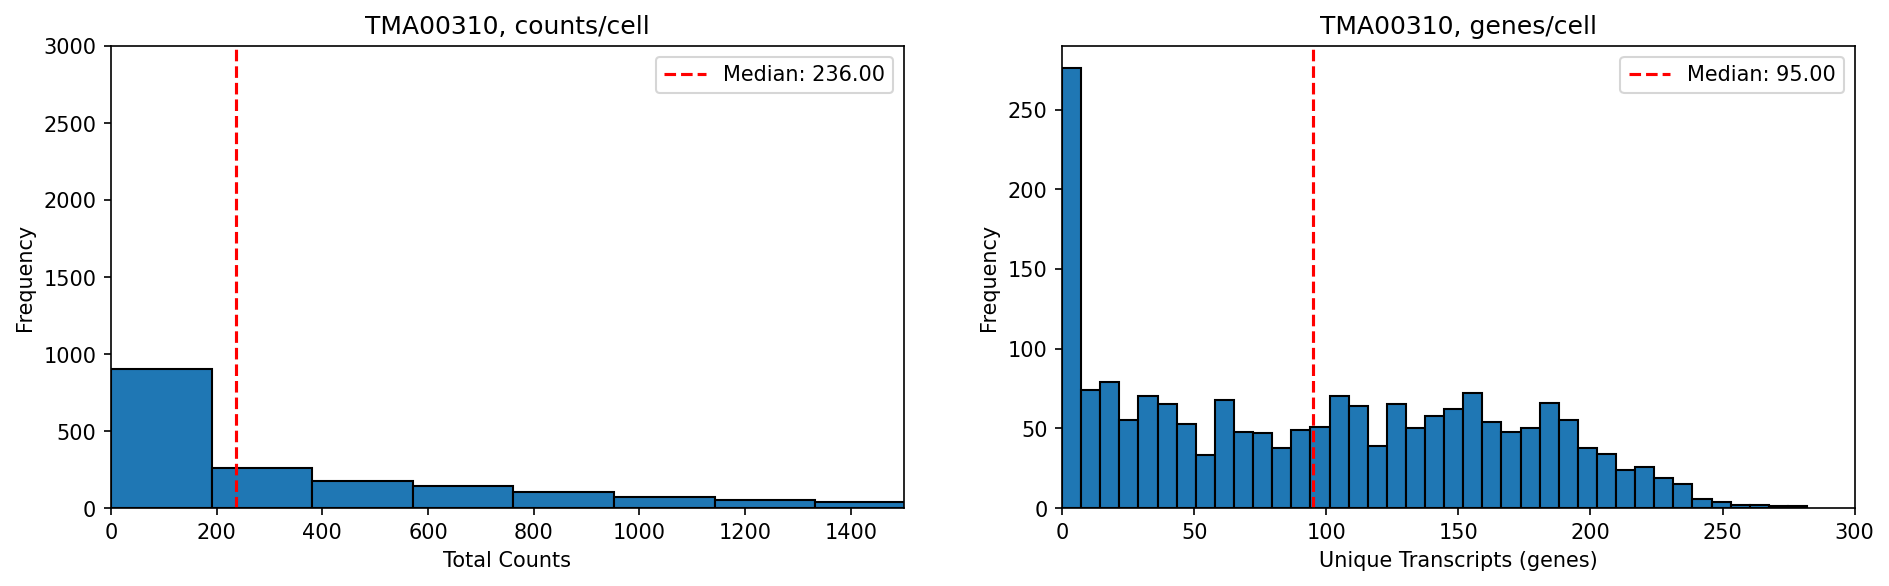

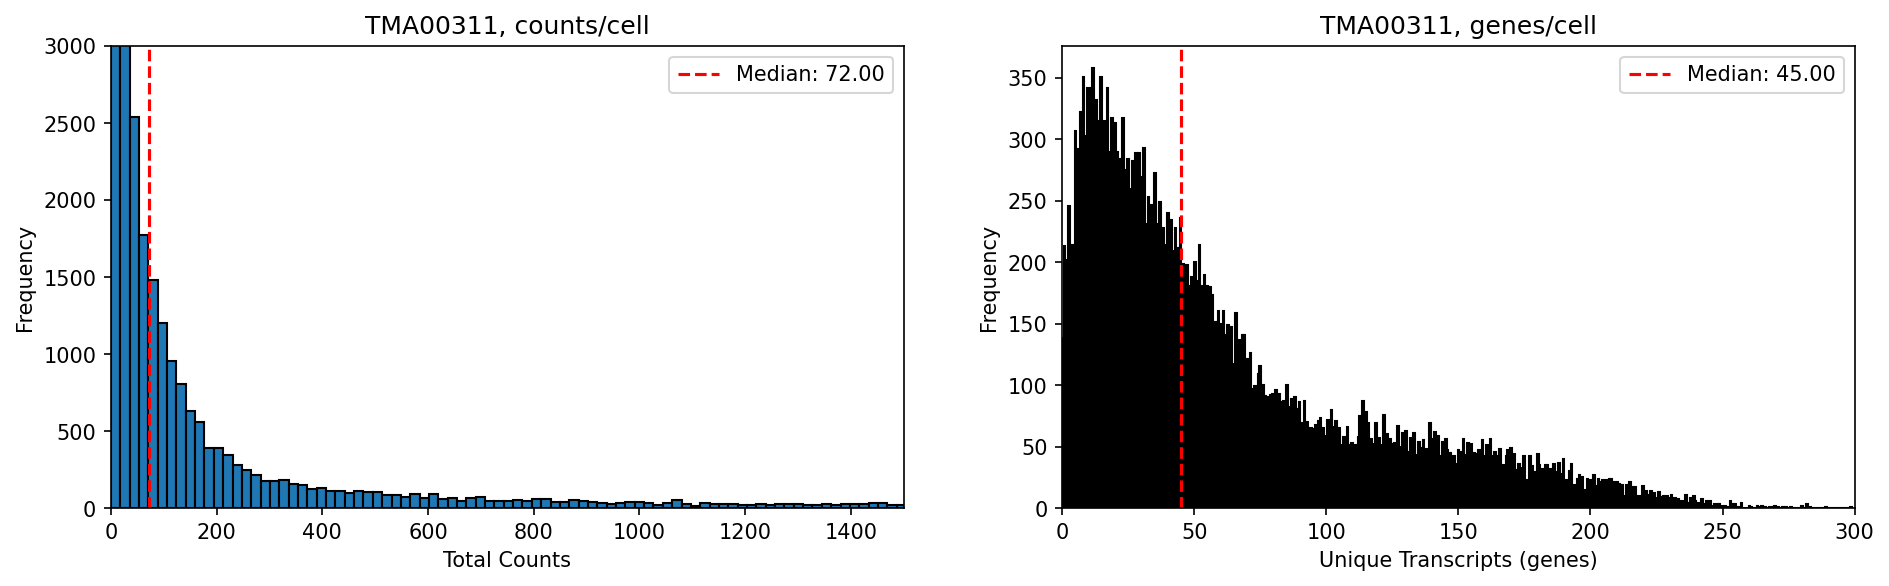

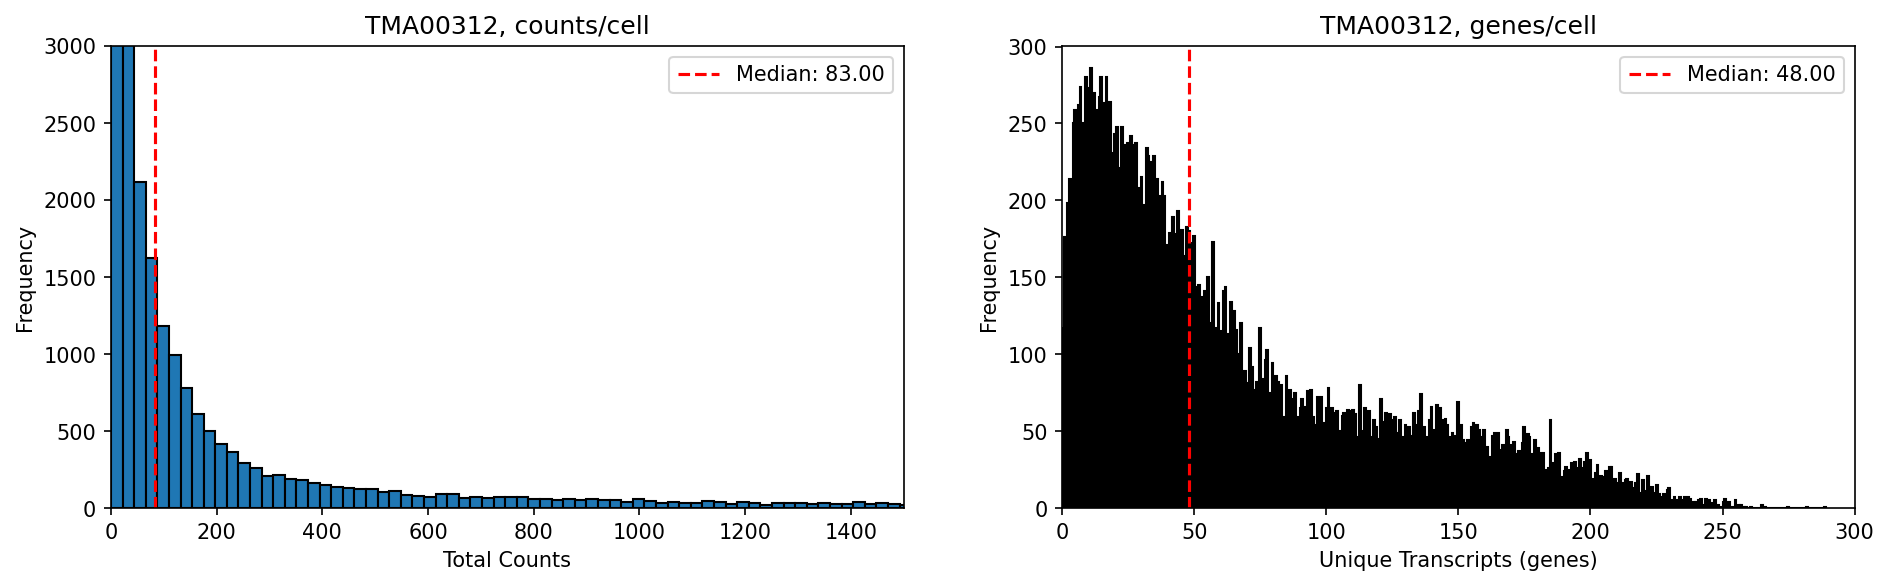

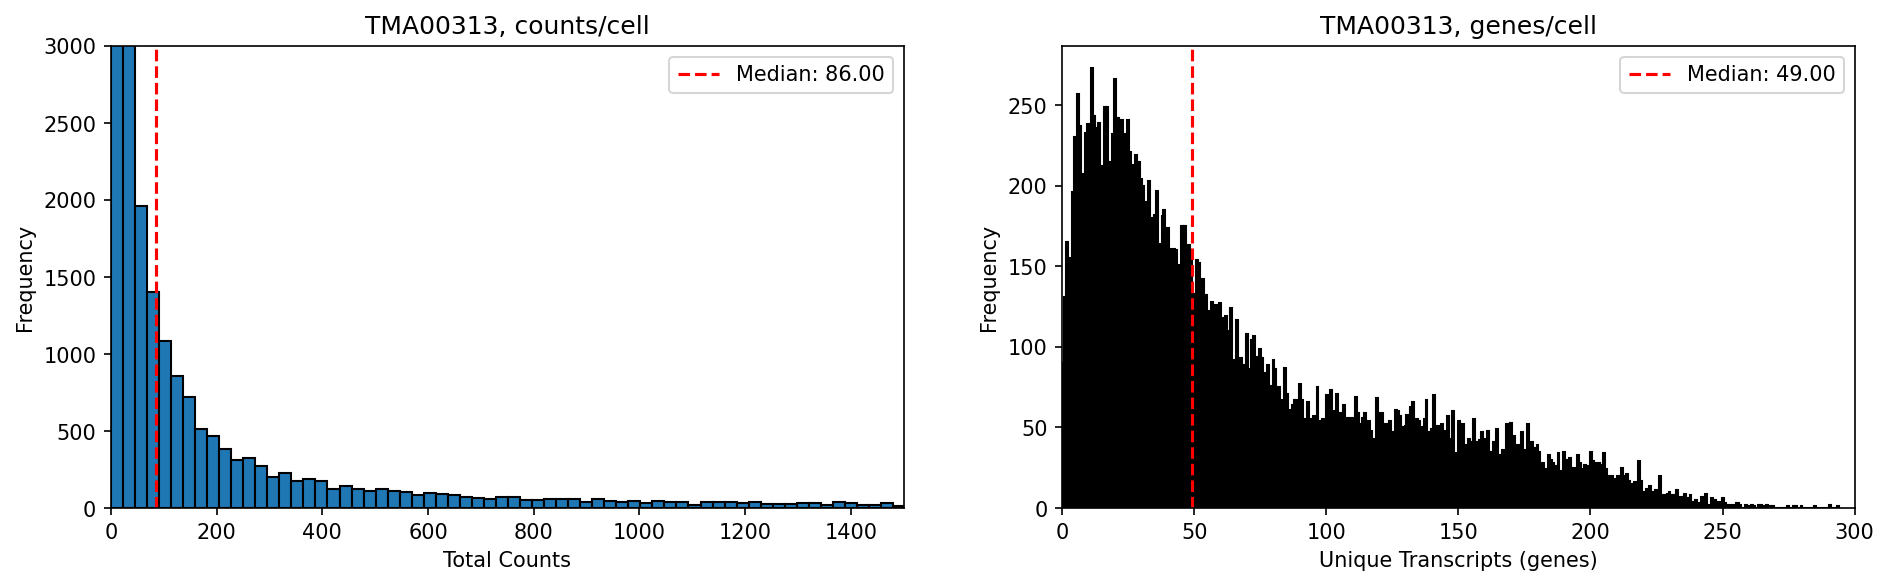

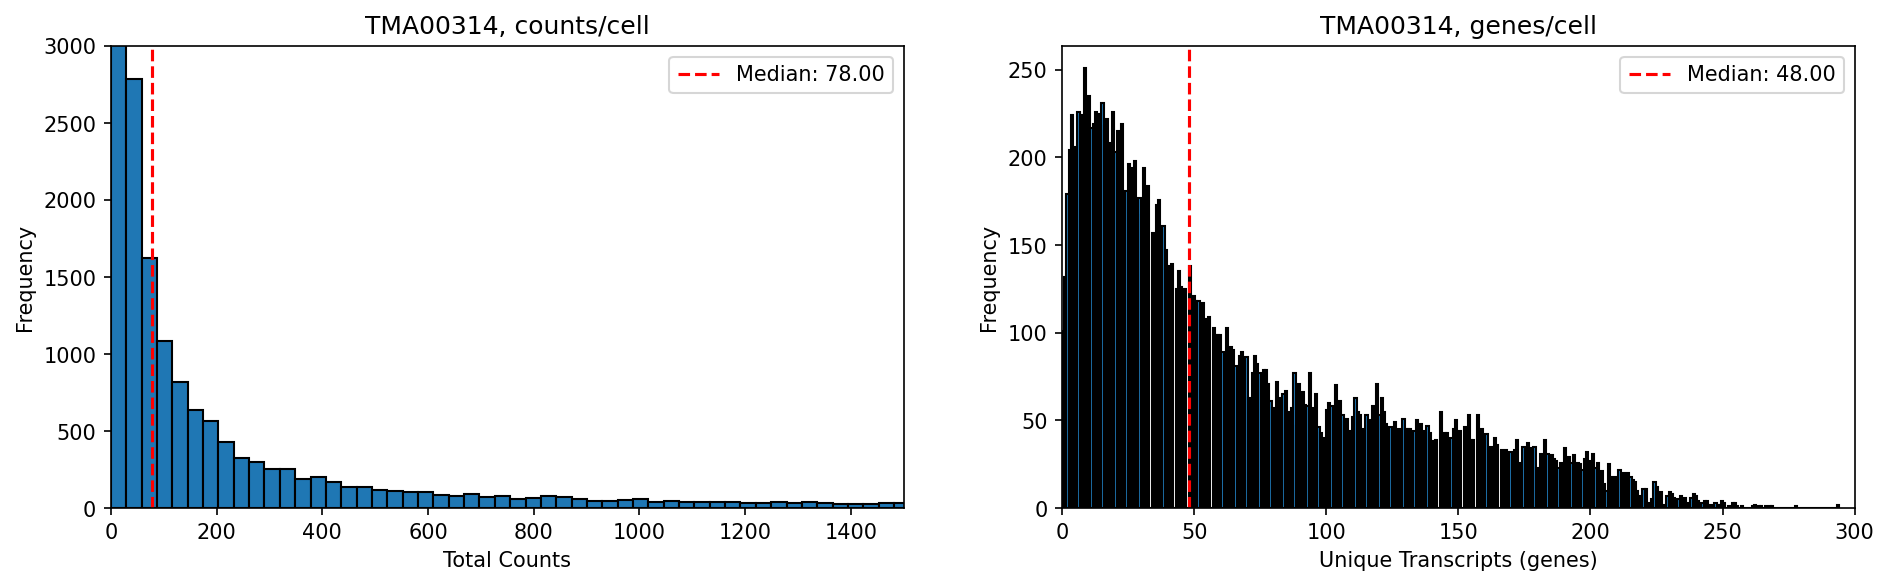

In [12]:
for adata in adata_list:
    sample_id = adata.obs['sample_id'].iloc[0]
    print(sample_id)

    # Calculate QC
    sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

    # Number of cells
    cell_num = adata.obs.shape[0]
    print(cell_num, 'cells')

    # Visualize QC
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    # Plot the first histogram: Total Counts
    counts_median = adata.obs["total_counts"].median()  
    axs[0].hist(adata.obs["total_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[0].set_title(sample_id + ", " + "counts/cell")
    axs[0].set_xlim(0, 1500)
    axs[0].set_ylim(0, 3000)
    axs[0].set_xlabel('Total Counts')
    axs[0].set_ylabel('Frequency')
    axs[0].axvline(counts_median, color='red', linestyle='--', label=f'Median: {counts_median:.2f}')  # Add vertical line
    axs[0].legend()  # Add legend for the median line

    # Plot the second histogram: Genes by Counts
    genes_median = adata.obs["n_genes_by_counts"].median()  
    axs[1].hist(adata.obs["n_genes_by_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[1].set_title(sample_id + ", " + "genes/cell")
    axs[1].set_xlim(0, 300)
    axs[1].set_xlabel('Unique Transcripts (genes)')
    axs[1].set_ylabel('Frequency')
    axs[1].axvline(genes_median, color='red', linestyle='--', label=f'Median: {genes_median:.2f}')  # Add vertical line
    axs[1].legend()  # Add legend for the median line

    # Save figure
    fig.savefig(os.path.join(fig_dir, sample_id + '_raw_QC.png'))

## Genes of interest

In [13]:
genes = adata.var
genes.head()

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1500009L16Rik,ENSMUSG00000087651,Gene Expression,Unknown,830,0.060420,0.058665,95.334982,1075.0,6.981006
6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown,5327,3.665243,1.540140,70.059577,65212.0,11.085414
Abcb1a,ENSMUSG00000040584,Gene Expression,Unknown,3206,0.444076,0.367470,81.980665,7901.0,8.974872
Ache,ENSMUSG00000023328,Gene Expression,Unknown,4605,1.617581,0.962251,74.117581,28780.0,10.267470
Acta2,ENSMUSG00000035783,Gene Expression,Unknown,556,0.037545,0.036857,96.875000,668.0,6.505784


In [14]:
# save panel
csv_path = os.path.join(metadata_dir, 'gene-panel.csv')
genes.to_csv(csv_path, index = True)

print(f'Gene panel saved at: {csv_path}')

Gene panel saved at: /home/workspace/projects/drg/metadata/gene-panel.csv


## Export Anndata

In [15]:
# export 01

for i, adata in enumerate(adata_list):
    sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
    output_file = os.path.join(h5ad_dir, f"{sample_name}.h5ad")
    
    adata.write(output_file)
    print(f"Saved: {output_file}")

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00303.h5ad


/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"


Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00304.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00305.h5ad


/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"


Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00306.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00307.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00308.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00309.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00310.h5ad


/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00311.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00312.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00313.h5ad


/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["sample_id"][0] if "sample_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2257/2863077922.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01a_raw/output_folder/TMA00314.h5ad


### Session info

In [16]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
